# Modelos de Despacho Social — SIN 2025

Este notebook implementa e avalia modelos de **otimização de despacho social** para o Sistema Interligado Nacional (SIN) do Brasil em 2025. O objetivo é determinar o despacho ótimo das usinas controláveis (térmica + nuclear) que minimiza custos totais respeitando restrições operacionais e requisitos de reserva.

## Formulação do Problema

O modelo minimiza:

$$
\min \sum_t \left[ c_1 g^n_t + \frac{c_2}{2}(g^n_t)^2 + \frac{\gamma}{2}(g^n_t - g^n_{t-1})^2 + \pi_u u_t + \pi_c c_t + \kappa R_t \right]
$$

sujeito a:
- **Balanço de potência**: $g^s_t + g^r_t + g^h_t + g^n_t = D_{net,t} + c_t - u_t$
- **Capacidade**: $0 \leq g^n_t \leq K_n$
- **Rampa**: $|g^n_t - g^n_{t-1}| \leq \rho$
- **Reserva mínima**: $R_t \geq z_\alpha \sigma_{\epsilon,t}$
- **Viabilidade de reserva**: $g^n_t + R_t \leq K_n$

## Estrutura do Notebook

1. **Carregamento de dados** e construção do painel via `pipeline.py`
2. **Definição do modelo** (parâmetros, solver CVXPY)
3. **Despacho com intercâmbio** ($D_{net} = D - x_{int}$)
4. **Despacho sem intercâmbio** (análise de sensibilidade, $D$)
5. **Métricas e comparação** com despacho observado
6. **Análise de preços-sombra** por regime operacional
7. **Visualizações temporais**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 200)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

from validate_model.pipeline import (
    SINPaths, build_panel, plot_temporal_window,
    SUBSYS_ORDER,
)

paths = SINPaths(root="validate_model", year=2025)
paths.summary()

ROOT: validate_model
Curva carga (4 arquivos): ['validate_model\\data\\demanda_efetiva\\CURVA_CARGA_NORDESTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_NORTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_SUDESTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_SUL_2025.csv']
Previsões   (4 arquivos): ['validate_model\\data\\demanda_esperada\\DEMANDA_NE_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_N_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_SE_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_S_2025.csv']
  Solar               : ✓ validate_model\data\producao_solar\fotovoltaicas_2025.csv
  Eólica              : ✓ validate_model\data\producao_eolica\eolicas_2025.csv
  Nuclear             : ✓ validate_model\data\producao_non_renewable\nuclear_2025.csv
  Térmica             : ✓ validate_model\data\producao_non_renewable\TERMICAS_2025.csv
  Intercâmbio SIN     : ✓ validate_model\data\intercambio\In

In [2]:
panel = build_panel(paths)
panel.head(5)

Carregando demanda efetiva...
  ✓ 28,512 linhas
Carregando geração por fonte...
  ✓ solar: 29,664 linhas
  ✓ wind: 29,664 linhas
  ✓ nuclear: 7,416 linhas
  ✓ thermal: 29,664 linhas
  ✓ hydro: 29,664 linhas
  Total de gerações: 126,072 linhas
Carregando intercâmbio interno...
  ✓ 33,600 linhas

Painel montado: 29,664 linhas
Subsistemas: ['N', 'NE', 'S', 'SE']
Período: 2025-01-01 00:00:00 → 2025-11-05 23:00:00


,din_instante,id_subsistema,hydro,nuclear,solar,thermal,wind,D,x_int,gs,gr,gh,g_nuc_obs,g_th_obs,gn_obs,D_net
0,2025-01-01 00:00:00,N,6818.532,0.0,0.0,1751.809,401.685,7097.751,-1698.553,0.0,401.685,6818.532,0.0,1751.809,1751.809,8796.304
1,2025-01-01 01:00:00,N,6798.411,0.0,0.0,1758.383,396.855,7053.337,-1725.848,0.0,396.855,6798.411,0.0,1758.383,1758.383,8779.185
2,2025-01-01 02:00:00,N,6794.287,0.0,0.0,1767.523,383.406,7244.130,-1517.420,0.0,383.406,6794.287,0.0,1767.523,1767.523,8761.550
3,2025-01-01 03:00:00,N,6798.598,0.0,0.0,1777.335,386.052,7255.306,-1514.693,0.0,386.052,6798.598,0.0,1777.335,1777.335,8769.999
4,2025-01-01 04:00:00,N,6740.686,0.0,0.0,1781.130,389.000,7232.931,-1483.948,0.0,389.000,6740.686,0.0,1781.130,1781.130,8716.879


## 1. Definição do Modelo de Despacho Social

### Parâmetros do modelo

| Parâmetro | Significado | Valor padrão |
|-----------|-------------|--------------|
| $K_n$ | Capacidade máxima térmica (MW) | estimado do p99.5 observado |
| $\rho$ | Limite de rampa (MW/h) | estimado do p99.5 de rampas observadas |
| $c_1, c_2$ | Custos lineares e quadráticos de geração | 0, 1e-4 |
| $\gamma$ | Penalidade de rampa (suavização) | 5.0 |
| $\pi_u$ | Custo de déficit (R$/MWh) | 10.000 |
| $\pi_c$ | Custo de curtailment (R$/MWh) | 10 |
| $\kappa$ | Custo de reserva (R$/MW) | 1.0 |
| $\alpha$ | Nível de risco para reserva | 0.05 (95% confiança) |

### Incerteza renovável

$\sigma_\epsilon$ é estimado como o desvio-padrão do erro de previsão da soma eólica+solar, calculado por mês e hora do dia para captar variações diurnas e sazonais.

In [3]:
from dataclasses import dataclass

@dataclass
class Params:
    Kn: float
    rho: float
    c1: float = 0.0
    c2: float = 1e-4
    gamma: float = 5.0
    pi_u: float = 1e4
    pi_c: float = 10.0
    alpha: float = 0.05
    kappa: float = 1.0


def estimate_Kn_rho(gn_obs: np.ndarray) -> tuple[float, float]:
    """Estima capacidade (Kn) e rampa (rho) a partir da geração controlável
    observada usando quantis altos (p99.5) para robustez a outliers."""
    g = np.asarray(gn_obs)
    g = g[np.isfinite(g)]
    if len(g) < 10:
        return 0.0, 0.0
    Kn = float(np.quantile(g, 0.995))
    rho = float(np.quantile(np.abs(np.diff(g)), 0.995)) if len(g) > 2 else 0.0
    return Kn, rho


def z_value(alpha: float) -> float:
    """Retorna o valor-z para nível de significância alpha (one-sided)."""
    table = {0.05: 1.645, 0.025: 1.96, 0.01: 2.326}
    return table.get(round(alpha, 4), 1.645)


def compute_sigma_eps_month_hour(panel_df: pd.DataFrame) -> pd.DataFrame:
    """Calcula sigma_eps (variabilidade renovável) por mês e hora do dia."""
    df = panel_df.copy()
    df["hour"] = df["din_instante"].dt.hour
    df["month"] = df["din_instante"].dt.month
    df["ren"] = df["gs"].fillna(0.0) + df["gr"].fillna(0.0)

    keys = ["id_subsistema", "month", "hour"]
    mu = df.groupby(keys)["ren"].mean().rename("mu")
    df = df.join(mu, on=keys)
    df["eps"] = df["ren"] - df["mu"]

    sig = df.groupby(keys)["eps"].std().rename("sigma_eps")
    df = df.join(sig, on=keys)
    df["sigma_eps"] = df["sigma_eps"].fillna(0.0)
    return df[["din_instante", "id_subsistema", "sigma_eps"]]


def compute_sigma_eps_hourly(panel_df: pd.DataFrame) -> pd.DataFrame:
    """Calcula sigma_eps por hora do dia (menos granular que mês×hora)."""
    df = panel_df.copy()
    df["hour"] = df["din_instante"].dt.hour
    df["ren"] = df["gs"].fillna(0.0) + df["gr"].fillna(0.0)

    keys = ["id_subsistema", "hour"]
    mu = df.groupby(keys)["ren"].mean().rename("mu")
    df = df.join(mu, on=keys)
    df["eps"] = df["ren"] - df["mu"]

    sig = df.groupby(keys)["eps"].std().rename("sigma_eps")
    df = df.join(sig, on=keys)
    df["sigma_eps"] = df["sigma_eps"].fillna(0.0)
    return df[["din_instante", "id_subsistema", "sigma_eps"]]

### Solver: Despacho Social via CVXPY

O solver formula o problema como programação quadrática convexa (QP) e resolve com OSQP (fallback: ECOS). Retorna o despacho ótimo, curtailment, déficit, reservas e preços-sombra (duais da restrição de balanço).

In [4]:
import cvxpy as cp


def dispatch_social(
    gs, gr, gh, D_net, sigma_eps, params: Params,
    g0: float = 0.0, force_cvxpy: bool = True,
):
    """Resolve o despacho social ótimo via programação convexa (CVXPY).

    Retorna: (gn, c, u, R, lam, sR, status)
        gn  - geração controlável ótima
        c   - curtailment
        u   - déficit
        R   - reserva alocada
        lam - preço-sombra (dual do balanço)
        sR  - shortfall de reserva (slack)
        status - status do solver
    """
    T = len(D_net)
    z = z_value(params.alpha)
    R_req = z * np.asarray(sigma_eps)

    gs = np.asarray(gs)
    gr = np.asarray(gr)
    gh = np.asarray(gh)
    D_net = np.asarray(D_net)

    # --- Heurística (fallback) ---
    if not force_cvxpy:
        g_req = D_net - gs - gr - gh
        gn = np.zeros(T)
        R = np.minimum(R_req, params.Kn)
        sR = np.maximum(R_req - R, 0.0)

        hi0 = max(0.0, params.Kn - R[0])
        gn[0] = np.clip(g_req[0], max(0.0, g0 - params.rho), min(hi0, g0 + params.rho))
        for t in range(1, T):
            lo = max(0.0, gn[t - 1] - params.rho)
            hi = min(max(0.0, params.Kn - R[t]), gn[t - 1] + params.rho)
            gn[t] = np.clip(g_req[t], lo, hi)

        e = gs + gr + gh + gn - D_net
        c = np.maximum(e, 0.0)
        u = np.maximum(-e, 0.0)
        lam = np.zeros(T)
        return gn, c, u, R, lam, sR, "heuristic"

    # --- Modelo CVXPY ---
    gn = cp.Variable(T)
    c_var = cp.Variable(T)
    u_var = cp.Variable(T)
    R_var = cp.Variable(T)
    sR_var = cp.Variable(T)

    constraints = [
        gn >= 0, gn <= params.Kn,
        c_var >= 0, u_var >= 0,
        R_var >= 0, sR_var >= 0,
        R_var + sR_var >= R_req,
        gn + R_var <= params.Kn,
        cp.abs(gn[0] - g0) <= params.rho,
    ]
    balance = (gs + gr + gh + gn == D_net + c_var - u_var)
    constraints.append(balance)
    if T > 1:
        constraints.append(cp.abs(gn[1:] - gn[:-1]) <= params.rho)

    obj = params.c1 * cp.sum(gn) + 0.5 * params.c2 * cp.sum_squares(gn)
    if T > 1:
        obj += 0.5 * params.gamma * cp.sum_squares(gn[1:] - gn[:-1])
    obj += params.pi_u * cp.sum(u_var) + params.pi_c * cp.sum(c_var)
    obj += params.kappa * cp.sum(R_var)
    obj += 1e6 * cp.sum(sR_var)

    prob = cp.Problem(cp.Minimize(obj), constraints)

    try:
        prob.solve(solver=cp.OSQP, verbose=False)
    except Exception:
        prob.solve(solver=cp.ECOS, verbose=False)

    status = prob.status
    if status not in ("optimal", "optimal_inaccurate"):
        return dispatch_social(gs, gr, gh, D_net, sigma_eps, params, g0=g0, force_cvxpy=False)

    lam = balance.dual_value

    def _bad_dual(v):
        if v is None:
            return True
        v = np.asarray(v).reshape(-1)
        return (not np.all(np.isfinite(v)) or
                np.nanmax(np.abs(v)) < 1e-9 or
                (np.nanmax(v) - np.nanmin(v)) < 1e-9)

    for fallback_solver in [cp.SCS, cp.ECOS]:
        if not _bad_dual(lam):
            break
        try:
            prob.solve(solver=fallback_solver, verbose=False, **({"max_iters": 20000} if fallback_solver == cp.SCS else {}))
        except Exception:
            pass
        status = prob.status
        lam = balance.dual_value

    if lam is None:
        lam = np.zeros(T)
    else:
        lam = np.asarray(lam).reshape(-1)

    return gn.value, c_var.value, u_var.value, R_var.value, lam, sR_var.value, status


print("dispatch_social definido com sucesso.")

dispatch_social definido com sucesso.


## 2. Funções Auxiliares: Métricas e Classificação de Regime

In [5]:
def metrics(y, yhat) -> dict:
    """Calcula MAE, RMSE e R² entre observado e predito."""
    y, yhat = np.asarray(y), np.asarray(yhat)
    m = np.isfinite(y) & np.isfinite(yhat)
    y, yhat = y[m], yhat[m]
    if len(y) == 0:
        return {"mae": np.nan, "rmse": np.nan, "r2": np.nan}
    return {
        "mae": float(mean_absolute_error(y, yhat)),
        "rmse": float(np.sqrt(mean_squared_error(y, yhat))),
        "r2": float(r2_score(y, yhat)),
    }


def per_subsystem_report(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Gera relatório de métricas por subsistema."""
    rows = []
    for ss, g in pred_df.groupby("id_subsistema"):
        m = metrics(g["gn_obs"], g["gn_hat"])
        rows.append({
            "subsistema": ss,
            "gn_mae": m["mae"],
            "gn_rmse": m["rmse"],
            "gn_r2": m["r2"],
            "balance_rmse": float(np.sqrt(np.mean(g["balance_err"] ** 2))) if len(g) > 0 else np.nan,
            "pct_curtail": float(np.mean(g["c_hat"] > 1e-6)),
            "pct_deficit": float(np.mean(g["u_hat"] > 1e-6)),
            "reserve_violation_rate": float(np.mean(g["reserve_slack"] < -1e-6)),
            "ramp_p99_obs": float(np.quantile(np.abs(np.diff(g["gn_obs"].values)), 0.99)) if len(g) > 2 else np.nan,
            "ramp_p99_hat": float(np.quantile(np.abs(np.diff(g["gn_hat"].values)), 0.99)) if len(g) > 2 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("subsistema")


def classify_regime(df: pd.DataFrame, eps_mw: float = 1.0) -> np.ndarray:
    """Classifica cada hora em: normal, curtailment, deficit ou both."""
    c = df["c_hat"].to_numpy()
    u = df["u_hat"].to_numpy()
    reg = np.full(len(df), "normal", dtype=object)
    reg[(c > eps_mw) & (u <= eps_mw)] = "curtailment"
    reg[(u > eps_mw) & (c <= eps_mw)] = "deficit"
    reg[(u > eps_mw) & (c > eps_mw)] = "both"
    return reg


def clean_slack_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Limpa artefatos numéricos nos slacks (c_hat, u_hat, R_hat)."""
    for col in ["c_hat", "u_hat", "R_hat"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
            df.loc[df[col].abs() < 1e-6, col] = 0.0
            df.loc[df[col] < 0, col] = 0.0
    return df

## 3. Função genérica de execução do despacho

Encapsula o loop por subsistema para evitar duplicação entre os cenários com e sem intercâmbio.

In [6]:
def run_dispatch(
    panel_df: pd.DataFrame,
    demand_col: str = "D_net",
    sigma_mode: str = "month_hour",
    output_path: str | None = None,
) -> pd.DataFrame:
    """Executa o despacho social para todos os subsistemas.

    Args:
        panel_df: painel unificado
        demand_col: coluna de demanda a usar ("D_net" com intercâmbio, "D" sem)
        sigma_mode: "month_hour" ou "hourly"
        output_path: caminho para salvar CSV (None para não salvar)

    Returns:
        DataFrame com previsões e diagnósticos
    """
    if sigma_mode == "month_hour":
        sigma_df = compute_sigma_eps_month_hour(panel_df)
    else:
        sigma_df = compute_sigma_eps_hourly(panel_df)

    df_otim = (panel_df
               .merge(sigma_df, on=["din_instante", "id_subsistema"], how="left")
               .fillna({"sigma_eps": 0.0})
               .sort_values(["id_subsistema", "din_instante"])
               .reset_index(drop=True))
    df_otim = df_otim.dropna(subset=[demand_col])

    results = []
    skipped = []

    for ss in SUBSYS_ORDER:
        g = df_otim[df_otim["id_subsistema"] == ss].copy().sort_values("din_instante").reset_index(drop=True)
        if len(g) == 0:
            skipped.append((ss, "sem dados"))
            continue

        g2 = g.dropna(subset=[demand_col])
        if len(g2) == 0:
            skipped.append((ss, f"sem {demand_col}"))
            continue

        Kn, rho = estimate_Kn_rho(g2["gn_obs"].values)
        params = Params(Kn=Kn, rho=rho)

        print(f"[{ss}] Kn={Kn:.1f} MW, rho={rho:.1f} MW/h, T={len(g2)}")

        gs_arr = g2["gs"].fillna(0.0).values
        gr_arr = g2["gr"].fillna(0.0).values
        gh_arr = g2["gh"].fillna(0.0).values
        Dn_arr = g2[demand_col].values
        sig_arr = g2["sigma_eps"].values
        g0 = float(g2["gn_obs"].iloc[0]) if np.isfinite(g2["gn_obs"].iloc[0]) else 0.0

        gn_hat, c_hat, u_hat, R_hat, lam_hat, sR_hat, status = dispatch_social(
            gs_arr, gr_arr, gh_arr, Dn_arr, sig_arr, params, g0=g0, force_cvxpy=True,
        )

        base_cols = ["din_instante", "id_subsistema", "D", "gs", "gr", "gh",
                     "gn_obs", "g_th_obs", "g_nuc_obs", "sigma_eps"]
        if "x_int" in g2.columns and demand_col == "D_net":
            base_cols += ["x_int", "D_net"]

        out = g2[base_cols].copy()
        out["gn_hat"] = gn_hat
        out["c_hat"] = c_hat
        out["u_hat"] = u_hat
        out["R_hat"] = R_hat
        out["lambda_hat"] = lam_hat
        out["reserve_shortfall"] = sR_hat
        out["solve_status"] = status

        dem_values = out[demand_col] if demand_col in out.columns else out["D"]
        out["balance_err"] = (out["gs"] + out["gr"] + out["gh"] + out["gn_hat"]
                              - (dem_values + out["c_hat"] - out["u_hat"]))
        out["headroom"] = params.Kn - out["gn_hat"]
        out["reserve_slack"] = out["headroom"] - out["R_hat"]

        results.append(out)

    if not results:
        print("⚠ Nenhum subsistema processado!")
        return pd.DataFrame()

    pred = pd.concat(results, ignore_index=True)
    pred = clean_slack_columns(pred)

    if output_path:
        pred.to_csv(output_path, index=False)
        print(f"\nSalvo: {output_path}")

    if skipped:
        print(f"Subsistemas pulados: {skipped}")

    return pred

## 4. Despacho Social COM Intercâmbio

Cenário principal: o modelo vê a demanda líquida $D_{net} = D - x_{int}$, incorporando importações/exportações entre subsistemas.

In [7]:
pred_interc = run_dispatch(
    panel,
    demand_col="D_net",
    sigma_mode="month_hour",
    output_path=os.path.join(paths.outputs, "predictions_social_dispatch_2025_with_intercambio.csv"),
)
pred_interc.head(10)

[N] Kn=3461.3 MW, rho=442.6 MW/h, T=7128


c:\Users\joaof\AppData\Local\Programs\Python\Python310\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[NE] Kn=2967.1 MW, rho=269.6 MW/h, T=7128
[SE] Kn=10279.3 MW, rho=705.4 MW/h, T=7128
[S] Kn=2087.1 MW, rho=143.4 MW/h, T=7128

Salvo: validate_model\outputs\predictions_social_dispatch_2025_with_intercambio.csv


,din_instante,id_subsistema,D,gs,gr,gh,gn_obs,g_th_obs,g_nuc_obs,sigma_eps,x_int,D_net,gn_hat,c_hat,u_hat,R_hat,lambda_hat,reserve_shortfall,solve_status,balance_err,headroom,reserve_slack
0,2025-01-01 00:00:00,N,7097.751,0.000,401.685,6818.532,1751.809,1751.809,0.0,126.964692,-1698.553,8796.304,1576.087,0.0,0.0,208.856919,0.0,0.0,heuristic,0.0,1885.19427,1676.337351
1,2025-01-01 01:00:00,N,7053.337,0.000,396.855,6798.411,1758.383,1758.383,0.0,127.783619,-1725.848,8779.185,1583.919,0.0,0.0,210.204053,0.0,0.0,heuristic,0.0,1877.36227,1667.158217
2,2025-01-01 02:00:00,N,7244.130,0.000,383.406,6794.287,1767.523,1767.523,0.0,128.791105,-1517.420,8761.550,1583.857,0.0,0.0,211.861368,0.0,0.0,heuristic,0.0,1877.42427,1665.562902
3,2025-01-01 03:00:00,N,7255.306,0.000,386.052,6798.598,1777.335,1777.335,0.0,127.309980,-1514.693,8769.999,1585.349,0.0,0.0,209.424916,0.0,0.0,heuristic,0.0,1875.93227,1666.507354
4,2025-01-01 04:00:00,N,7232.931,0.000,389.000,6740.686,1781.130,1781.130,0.0,130.096797,-1483.948,8716.879,1587.193,0.0,0.0,214.009231,0.0,0.0,heuristic,0.0,1874.08827,1660.079039
5,2025-01-01 05:00:00,N,7229.362,10.549,345.457,5918.031,1778.974,1778.974,0.0,132.382830,-631.195,7860.557,1586.520,0.0,0.0,217.769756,0.0,0.0,heuristic,0.0,1874.76127,1656.991514
6,2025-01-01 06:00:00,N,7005.631,142.440,248.182,4492.022,1773.585,1773.585,0.0,141.152779,536.780,6468.851,1586.207,0.0,0.0,232.196321,0.0,0.0,heuristic,0.0,1875.07427,1642.877949
7,2025-01-01 07:00:00,N,6807.913,477.473,167.930,3668.508,1745.956,1745.956,0.0,147.564063,913.928,5893.985,1580.074,0.0,0.0,242.742884,0.0,0.0,heuristic,0.0,1881.20727,1638.464386
8,2025-01-01 08:00:00,N,6774.526,881.953,131.101,3159.354,1726.866,1726.866,0.0,159.915240,1023.577,5750.949,1578.541,0.0,0.0,263.060571,0.0,0.0,heuristic,0.0,1882.74027,1619.679699
9,2025-01-01 09:00:00,N,6772.877,1223.714,116.666,3178.103,1719.707,1719.707,0.0,167.343844,669.319,6103.558,1585.075,0.0,0.0,275.280623,0.0,0.0,heuristic,0.0,1876.20627,1600.925647


### Métricas: Despacho com Intercâmbio

In [8]:
if not pred_interc.empty:
    rep_interc = per_subsystem_report(pred_interc)
    display(rep_interc)

    print("\nDistribuição dos preços-sombra (lambda_hat):")
    display(pred_interc.groupby("id_subsistema")["lambda_hat"].describe().round(2))

,subsistema,gn_mae,gn_rmse,gn_r2,balance_rmse,pct_curtail,pct_deficit,reserve_violation_rate,ramp_p99_obs,ramp_p99_hat
0,N,116.670167,137.309531,0.969895,0.000000e+00,0.003788,0.040544,0.000000,349.28910,350.035440
1,NE,537.316709,787.077877,-0.836539,7.539152e-08,0.075196,0.895062,0.006453,219.87732,269.594540
2,S,412.316950,619.605453,-1.095017,1.263799e-07,0.614338,0.467172,0.007155,106.61388,143.421232
3,SE,315.368496,501.177958,0.928618,2.346192e-08,0.710157,0.153900,0.000000,540.61764,705.381370



Distribuição dos preços-sombra (lambda_hat):


,count,mean,std,min,25%,50%,75%,max
id_subsistema,,,,,,,,
N,7128.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00
NE,7128.0,-8847.71,3167.18,-10000.09,-10000.00,-10000.0,-10000.0,11.21
S,7128.0,-2449.32,4288.56,-10000.04,-550.31,10.0,10.0,12.69
SE,7128.0,-1266.37,3272.66,-10000.00,-22.93,10.0,10.0,10.07


## 5. Despacho Social SEM Intercâmbio (Análise de Sensibilidade)

Cada subsistema é tratado como **isolado**: precisa gerar 100% da demanda local ($D$), sem importar ou exportar. Diferenças em relação ao cenário com intercâmbio quantificam o valor da interconexão.

$$
g^s_t + g^r_t + g^h_t + g^n_t = D_{t,s} + c_t - u_t
$$

In [9]:
pred_no_interc = run_dispatch(
    panel,
    demand_col="D",
    sigma_mode="hourly",
    output_path=os.path.join(paths.outputs, "predictions_social_dispatch_2025.csv"),
)
pred_no_interc.head(10)

[N] Kn=3461.3 MW, rho=442.6 MW/h, T=7128


c:\Users\joaof\AppData\Local\Programs\Python\Python310\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[NE] Kn=2967.1 MW, rho=269.6 MW/h, T=7128
[SE] Kn=10279.3 MW, rho=705.4 MW/h, T=7128
[S] Kn=2087.1 MW, rho=143.4 MW/h, T=7128

Salvo: validate_model\outputs\predictions_social_dispatch_2025.csv


,din_instante,id_subsistema,D,gs,gr,gh,gn_obs,g_th_obs,g_nuc_obs,sigma_eps,gn_hat,c_hat,u_hat,R_hat,lambda_hat,reserve_shortfall,solve_status,balance_err,headroom,reserve_slack
0,2025-01-01 00:00:00,N,7097.751,0.000,401.685,6818.532,1751.809,1751.809,0.0,139.963584,2194.365360,2316.831360,0.0,230.240096,10.000000,-7.974454e-12,optimal_inaccurate,0.000000e+00,1266.915910,1036.675814
1,2025-01-01 01:00:00,N,7053.337,0.000,396.855,6798.411,1758.383,1758.383,0.0,141.890896,2238.170991,2380.099991,0.0,233.410523,10.000000,-7.848167e-12,optimal_inaccurate,0.000000e+00,1223.110279,989.699756
2,2025-01-01 02:00:00,N,7244.130,0.000,383.406,6794.287,1767.523,1767.523,0.0,147.825749,2284.021385,2217.584385,0.0,243.173358,10.000000,-7.744194e-12,optimal_inaccurate,0.000000e+00,1177.259885,934.086527
3,2025-01-01 03:00:00,N,7255.306,0.000,386.052,6798.598,1777.335,1777.335,0.0,147.371308,2331.917460,2261.261460,0.0,242.425802,10.000000,-7.790926e-12,optimal_inaccurate,0.000000e+00,1129.363810,886.938008
4,2025-01-01 04:00:00,N,7232.931,0.000,389.000,6740.686,1781.130,1781.130,0.0,149.509890,2381.860173,2278.615173,0.0,245.943770,10.000000,-7.977462e-12,optimal_inaccurate,1.818989e-12,1079.421097,833.477328
5,2025-01-01 05:00:00,N,7229.362,10.549,345.457,5918.031,1778.974,1778.974,0.0,153.732724,2433.850523,1478.525523,0.0,252.890331,10.000000,-7.877865e-12,optimal_inaccurate,1.818989e-12,1027.430747,774.540416
6,2025-01-01 06:00:00,N,7005.631,142.440,248.182,4492.022,1773.585,1773.585,0.0,187.838214,2487.889550,364.902550,0.0,308.993861,10.000000,-7.706342e-12,optimal_inaccurate,0.000000e+00,973.391720,664.397858
7,2025-01-01 07:00:00,N,6807.913,477.473,167.930,3668.508,1745.956,1745.956,0.0,252.688069,2543.978335,49.976335,0.0,415.671874,10.000000,-7.770511e-12,optimal_inaccurate,1.818989e-12,917.302935,501.631061
8,2025-01-01 08:00:00,N,6774.526,881.953,131.101,3159.354,1726.866,1726.866,0.0,319.649660,2602.118000,0.000000,0.0,525.823691,-322.950256,-7.944728e-12,optimal_inaccurate,0.000000e+00,859.163270,333.339579
9,2025-01-01 09:00:00,N,6772.877,1223.714,116.666,3178.103,1719.707,1719.707,0.0,360.169304,2595.719656,341.325656,0.0,592.478504,10.000000,-7.900181e-12,optimal_inaccurate,0.000000e+00,865.561614,273.083110


### Métricas: Despacho sem Intercâmbio

In [10]:
if not pred_no_interc.empty:
    rep_no_interc = per_subsystem_report(pred_no_interc)
    display(rep_no_interc)

,subsistema,gn_mae,gn_rmse,gn_r2,balance_rmse,pct_curtail,pct_deficit,reserve_violation_rate,ramp_p99_obs,ramp_p99_hat
0,N,851.546068,1029.468387,-0.692233,2.547379e-07,0.641835,0.416105,0.000000,349.28910,131.313585
1,NE,596.015305,832.201464,-1.053155,7.439263e-08,0.953844,0.520202,0.492284,219.87732,0.002202
2,S,492.218100,606.436111,-1.006907,7.003893e-08,0.240600,0.800224,0.026235,106.61388,143.420886
3,SE,2721.939993,3184.917420,-1.882709,2.258130e-07,0.367144,0.808642,0.157688,540.61764,705.381705


### Comparação: Impacto do Intercâmbio

Comparação de métricas: com intercâmbio vs. sem intercâmbio
(delta > 0 indica que intercâmbio melhora a métrica)


,subsistema,MAE_interc,RMSE_interc,R2_interc,MAE_sem,RMSE_sem,R2_sem,delta_RMSE,delta_R2
0,N,116.67,137.31,0.97,851.55,1029.47,-0.69,892.16,1.66
1,NE,537.32,787.08,-0.84,596.02,832.20,-1.05,45.12,0.22
2,S,412.32,619.61,-1.10,492.22,606.44,-1.01,-13.17,-0.09
3,SE,315.37,501.18,0.93,2721.94,3184.92,-1.88,2683.74,2.81


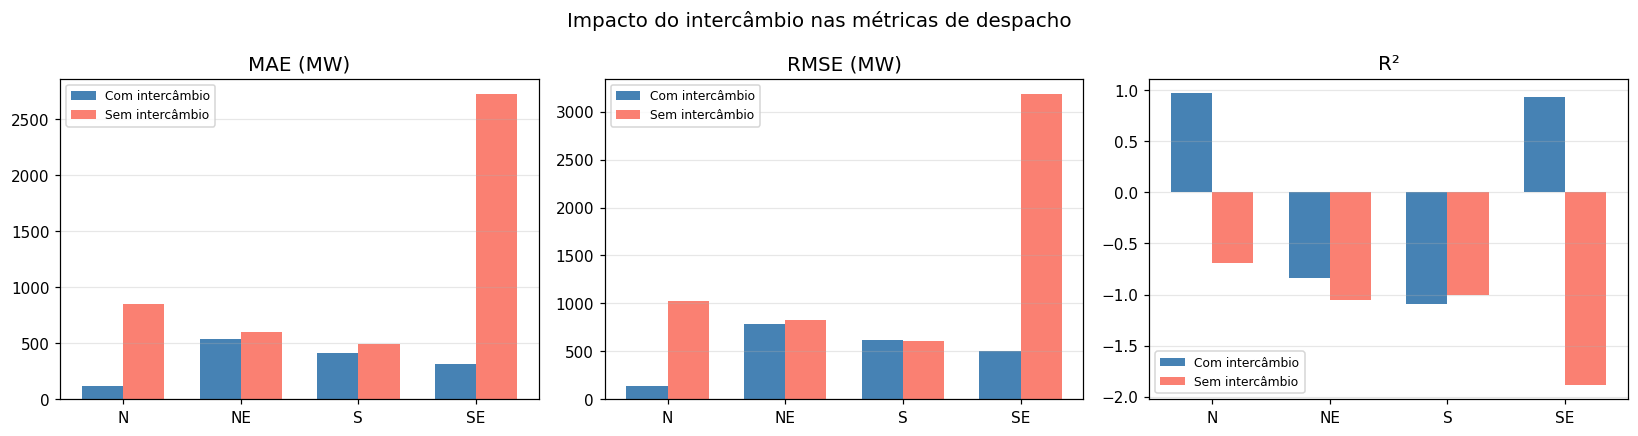

In [11]:
if not pred_interc.empty and not pred_no_interc.empty:
    comp = rep_interc[["subsistema", "gn_mae", "gn_rmse", "gn_r2"]].rename(
        columns={"gn_mae": "MAE_interc", "gn_rmse": "RMSE_interc", "gn_r2": "R2_interc"}
    ).merge(
        rep_no_interc[["subsistema", "gn_mae", "gn_rmse", "gn_r2"]].rename(
            columns={"gn_mae": "MAE_sem", "gn_rmse": "RMSE_sem", "gn_r2": "R2_sem"}
        ),
        on="subsistema",
    )
    comp["delta_RMSE"] = comp["RMSE_sem"] - comp["RMSE_interc"]
    comp["delta_R2"] = comp["R2_interc"] - comp["R2_sem"]

    print("Comparação de métricas: com intercâmbio vs. sem intercâmbio")
    print("(delta > 0 indica que intercâmbio melhora a métrica)")
    display(comp.round(2))

    # Gráfico comparativo
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(len(comp))
    w = 0.35
    for ax, (m1, m2, title) in zip(axes, [
        ("MAE_interc", "MAE_sem", "MAE (MW)"),
        ("RMSE_interc", "RMSE_sem", "RMSE (MW)"),
        ("R2_interc", "R2_sem", "R²"),
    ]):
        ax.bar(x - w/2, comp[m1], w, label="Com intercâmbio", color="steelblue")
        ax.bar(x + w/2, comp[m2], w, label="Sem intercâmbio", color="salmon")
        ax.set_xticks(x)
        ax.set_xticklabels(comp["subsistema"])
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")
    fig.suptitle("Impacto do intercâmbio nas métricas de despacho", fontsize=13)
    fig.tight_layout()
    plt.show()

## 6. Análise de Preços-Sombra por Regime Operacional

O preço-sombra ($\lambda_t$) é o custo marginal da energia — quanto o custo total mudaria se precisássemos entregar 1 MWh a mais. Separamos em três regimes:

- **Déficit** ($u_t > 0$): preço bate no teto $\pi_u$ (escassez severa)
- **Curtailment** ($c_t > 0$): preço próximo de zero ou negativo (excesso renovável)
- **Normal**: preço reflete custo marginal térmico real

PREÇOS-SOMBRA — COM INTERCÂMBIO


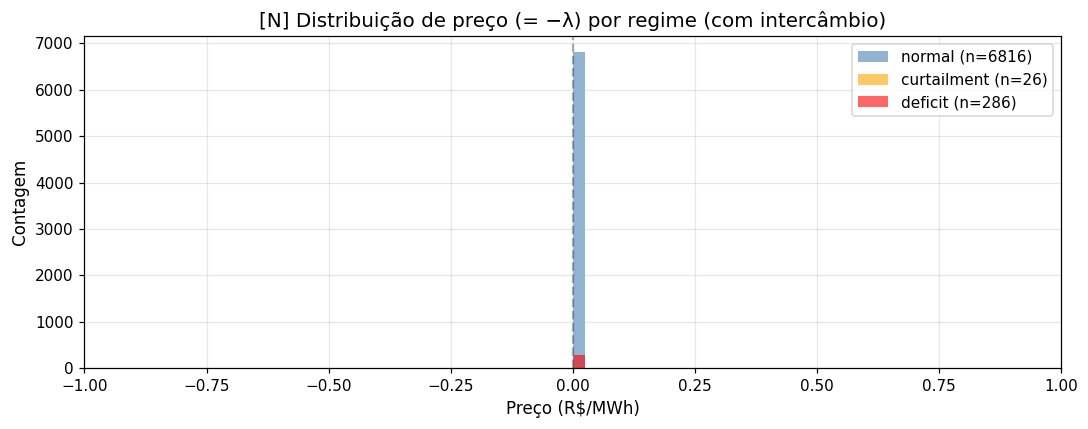

  [N] normal      : n= 6816, média=     0.0, mediana=     0.0, min=    -0.0, max=    -0.0
  [N] curtailment : n=   26, média=     0.0, mediana=     0.0, min=    -0.0, max=    -0.0
  [N] deficit     : n=  286, média=     0.0, mediana=     0.0, min=    -0.0, max=    -0.0


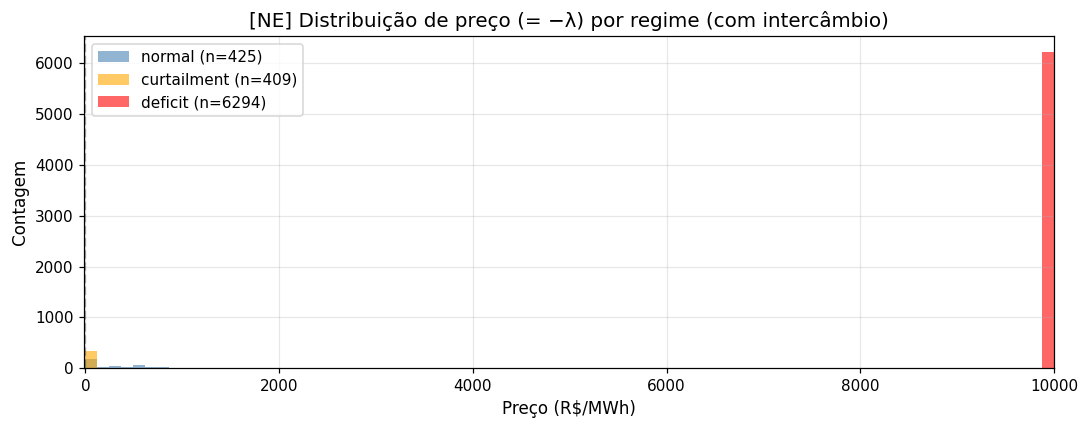

  [NE] normal      : n=  425, média=   307.2, mediana=   243.6, min=   -10.0, max=  1962.8
  [NE] curtailment : n=  409, média=   -10.0, mediana=   -10.0, min=   -11.2, max=    -9.2
  [NE] deficit     : n= 6294, média= 10000.0, mediana= 10000.0, min=  9998.4, max= 10000.1


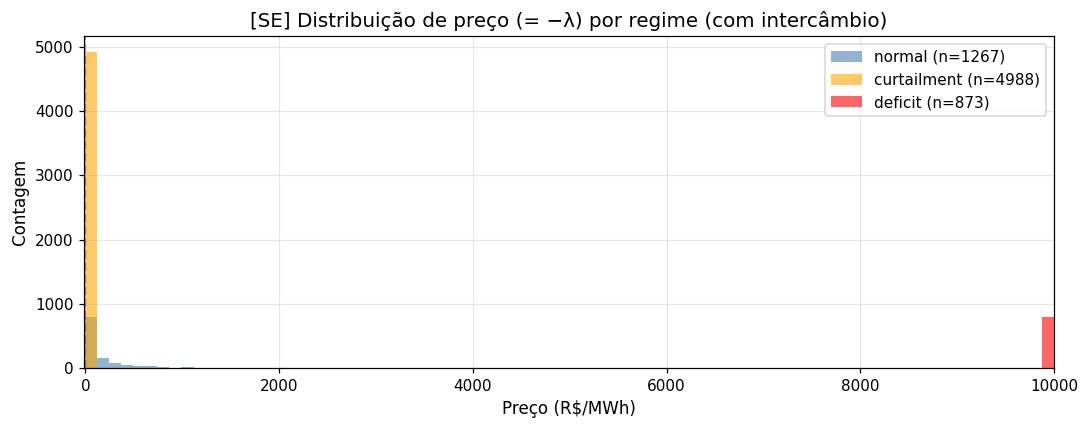

  [SE] normal      : n= 1267, média=   273.5, mediana=    70.0, min=   -10.0, max=  3621.8
  [SE] curtailment : n= 4988, média=   -10.0, mediana=   -10.0, min=   -10.1, max=   -10.0
  [SE] deficit     : n=  873, média= 10000.0, mediana= 10000.0, min= 10000.0, max= 10000.0


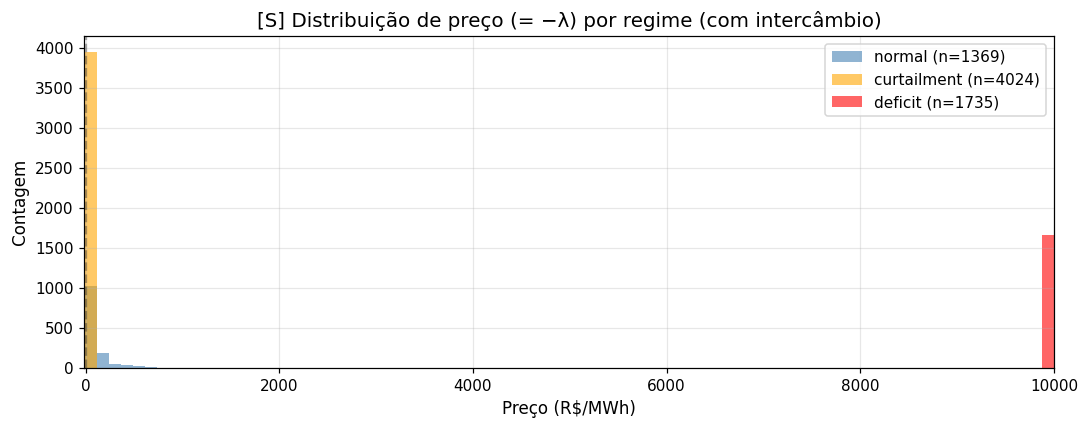

  [S] normal      : n= 1369, média=   109.0, mediana=    24.8, min=   -10.0, max= 10000.0
  [S] curtailment : n= 4024, média=   -10.1, mediana=   -10.0, min=   -12.7, max=    -6.9
  [S] deficit     : n= 1735, média= 10000.0, mediana= 10000.0, min= 10000.0, max= 10000.0


In [12]:
def plot_price_by_regime(pred_df: pd.DataFrame, title_suffix: str = ""):
    """Plota distribuição de preços-sombra por regime para cada subsistema."""
    df = pred_df.copy()
    df["regime"] = classify_regime(df)
    df["price_hat"] = -pd.to_numeric(df["lambda_hat"], errors="coerce")

    for ss in SUBSYS_ORDER:
        g = df[df["id_subsistema"] == ss]
        if len(g) == 0:
            continue

        allx = g["price_hat"].dropna().values
        if len(allx) == 0:
            continue

        q1, q99 = np.quantile(allx, [0.01, 0.99])
        if abs(q99 - q1) < 1e-9:
            q1, q99 = float(allx[0]) - 1.0, float(allx[0]) + 1.0

        fig, ax = plt.subplots(figsize=(10, 4))
        regime_colors = {
            "normal": "steelblue", "curtailment": "orange",
            "deficit": "red", "both": "purple",
        }
        for regime, color in regime_colors.items():
            x = g.loc[g["regime"] == regime, "price_hat"].dropna().values
            if len(x) == 0:
                continue
            ax.hist(x, bins=80, range=(q1, q99), alpha=0.6, color=color,
                    label=f"{regime} (n={len(x)})")

        ax.axvline(0, linestyle="--", alpha=0.3, color="black")
        ax.set_xlim(q1, q99)
        ax.set_title(f"[{ss}] Distribuição de preço (= −λ) por regime {title_suffix}")
        ax.set_xlabel("Preço (R$/MWh)")
        ax.set_ylabel("Contagem")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        plt.show()

        # Estatísticas por regime
        for regime in ["normal", "curtailment", "deficit"]:
            x = g.loc[g["regime"] == regime, "price_hat"].dropna()
            n = len(x)
            if n > 0:
                print(f"  [{ss}] {regime:12s}: n={n:5d}, "
                      f"média={x.mean():8.1f}, mediana={x.median():8.1f}, "
                      f"min={x.min():8.1f}, max={x.max():8.1f}")

if not pred_interc.empty:
    print("=" * 70)
    print("PREÇOS-SOMBRA — COM INTERCÂMBIO")
    print("=" * 70)
    plot_price_by_regime(pred_interc, "(com intercâmbio)")

PREÇOS-SOMBRA — SEM INTERCÂMBIO


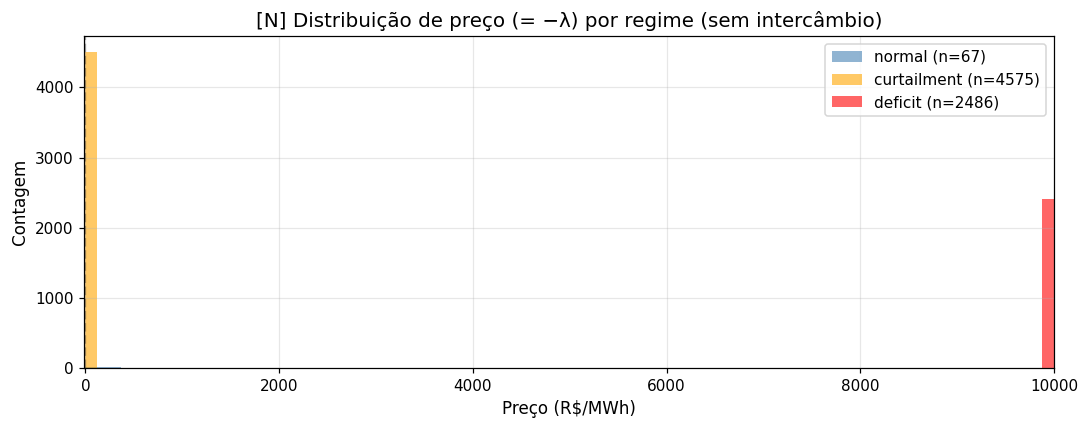

  [N] normal      : n=   67, média=   377.3, mediana=   202.7, min=    -4.6, max= 10000.0
  [N] curtailment : n= 4575, média=   -10.0, mediana=   -10.0, min=   -10.0, max=   -10.0
  [N] deficit     : n= 2486, média= 10000.0, mediana= 10000.0, min= 10000.0, max= 10000.0


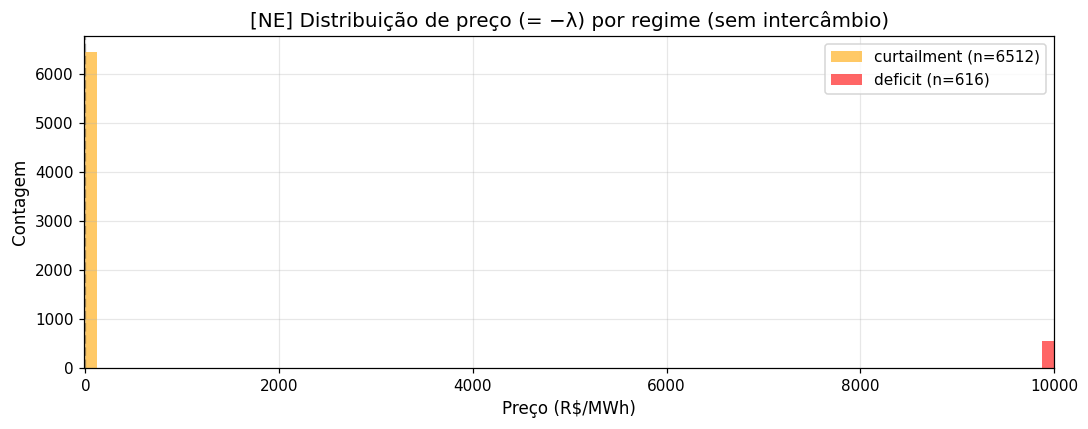

  [NE] curtailment : n= 6512, média=   -10.0, mediana=   -10.0, min=   -10.4, max=    -9.9
  [NE] deficit     : n=  616, média= 10000.0, mediana= 10000.0, min= 10000.0, max= 10000.0


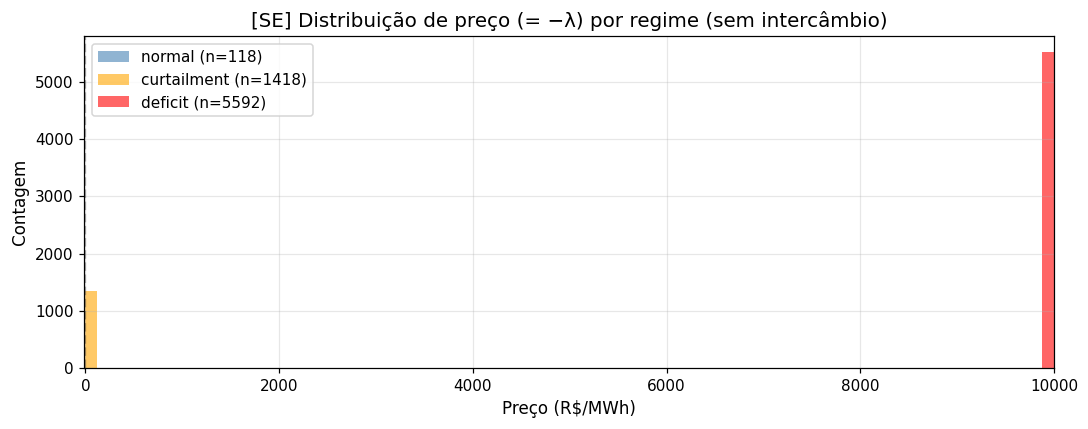

  [SE] normal      : n=  118, média=  1180.9, mediana=   926.9, min=    12.8, max=  4444.2
  [SE] curtailment : n= 1418, média=   -10.1, mediana=   -10.0, min=   -13.5, max=   -10.0
  [SE] deficit     : n= 5592, média= 10000.0, mediana= 10000.0, min=  9999.9, max= 10000.1


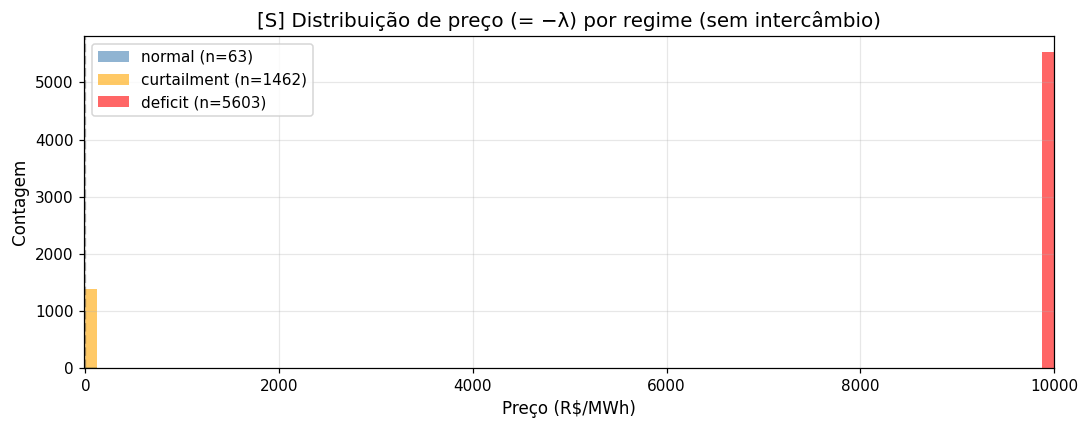

  [S] normal      : n=   63, média=   620.3, mediana=   300.9, min=   -10.0, max= 10000.0
  [S] curtailment : n= 1462, média=   -10.0, mediana=   -10.0, min=   -10.0, max=    -9.0
  [S] deficit     : n= 5603, média= 10000.0, mediana= 10000.0, min= 10000.0, max= 10000.1


In [13]:
if not pred_no_interc.empty:
    print("=" * 70)
    print("PREÇOS-SOMBRA — SEM INTERCÂMBIO")
    print("=" * 70)
    plot_price_by_regime(pred_no_interc, "(sem intercâmbio)")

## 7. Visualização de Séries Temporais

Janelas temporais representativas mostrando demanda, geração renovável, hidrelétrica, despacho otimizado vs. observado, curtailment e déficit.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Primeira semana (Janeiro): 2025-01-01 → 2025-01-07
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


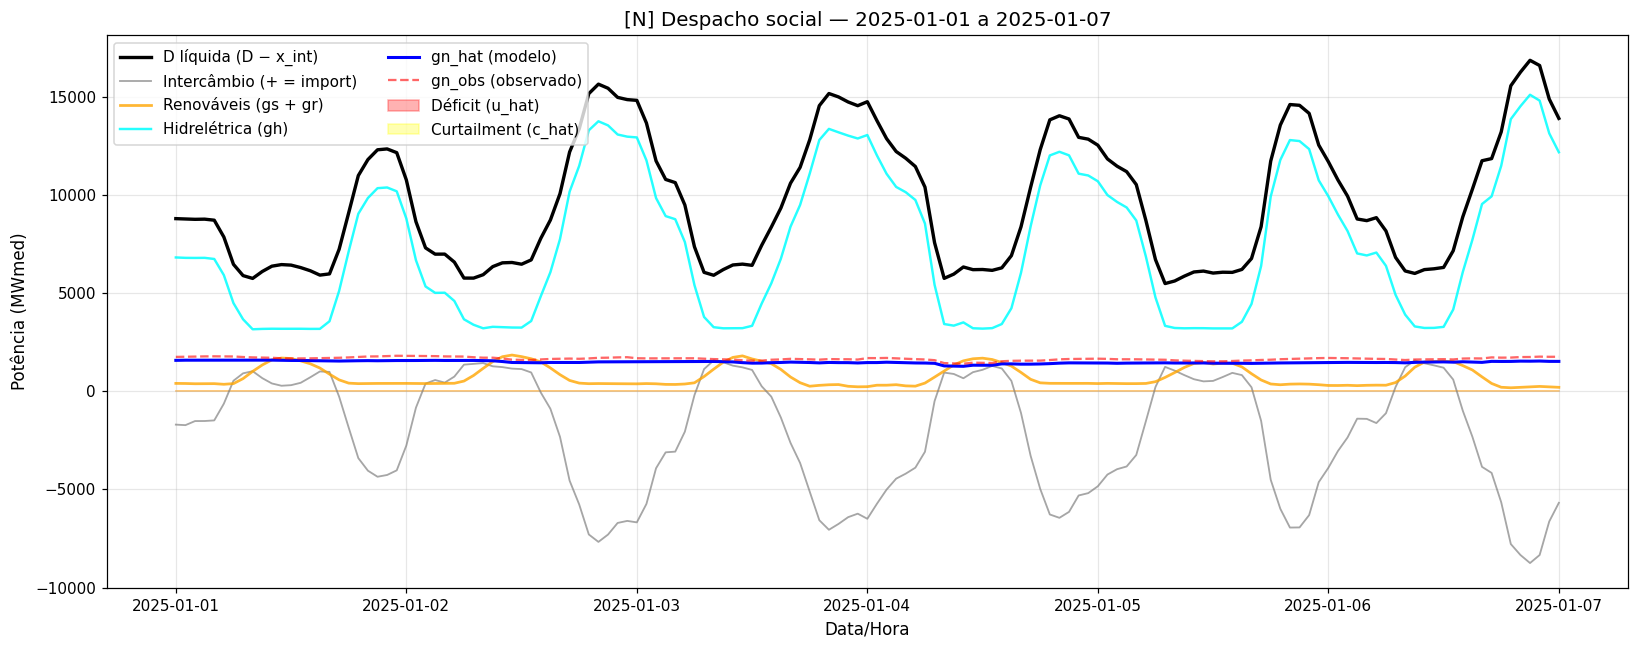

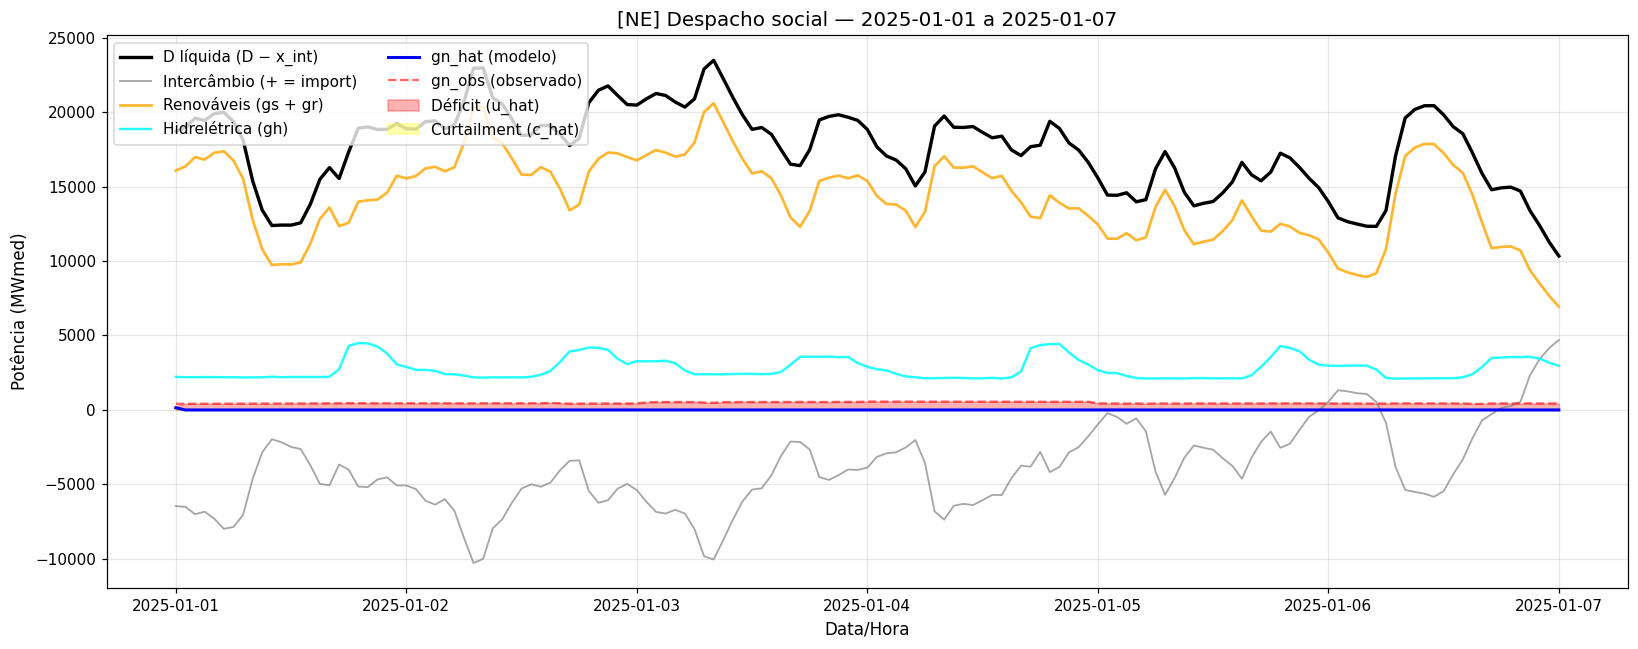

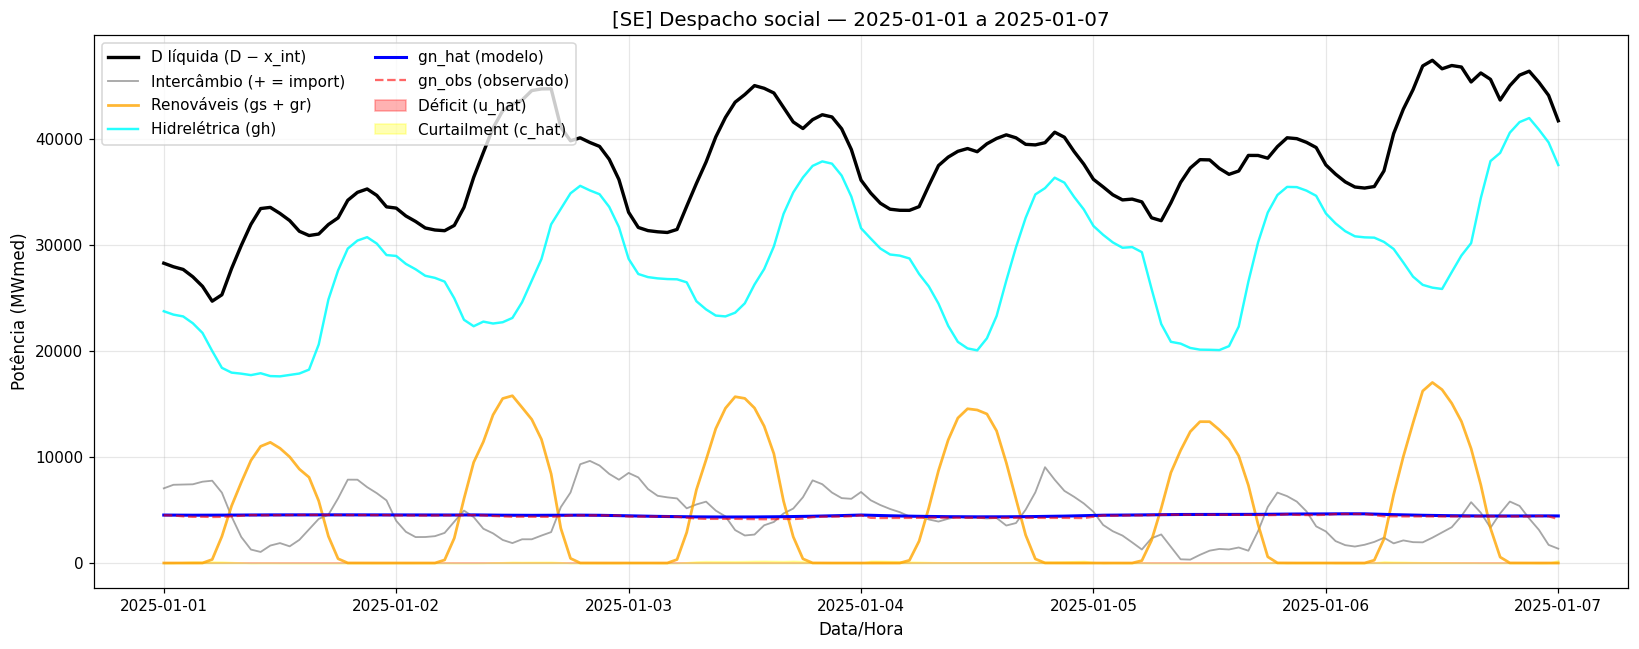

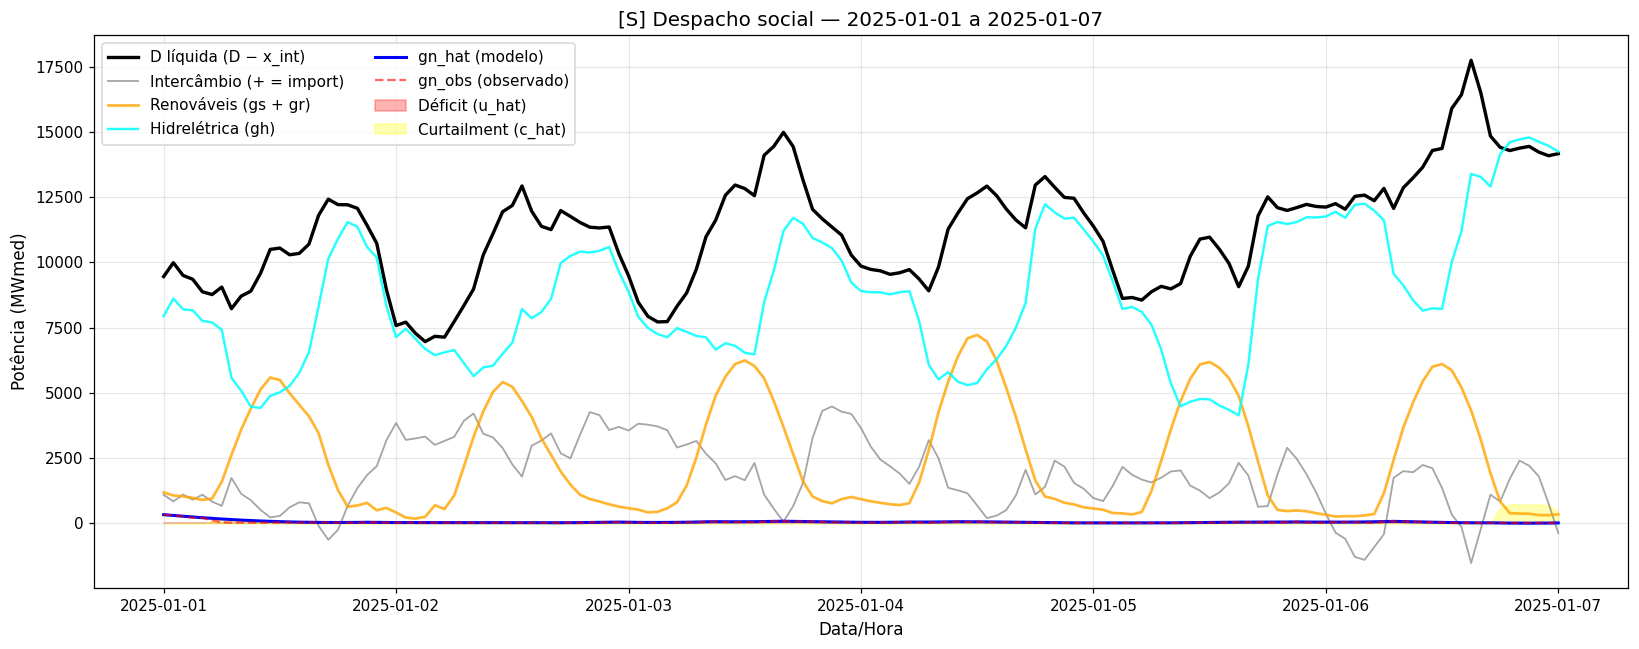


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Primeira semana de Junho: 2025-06-01 → 2025-06-07
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


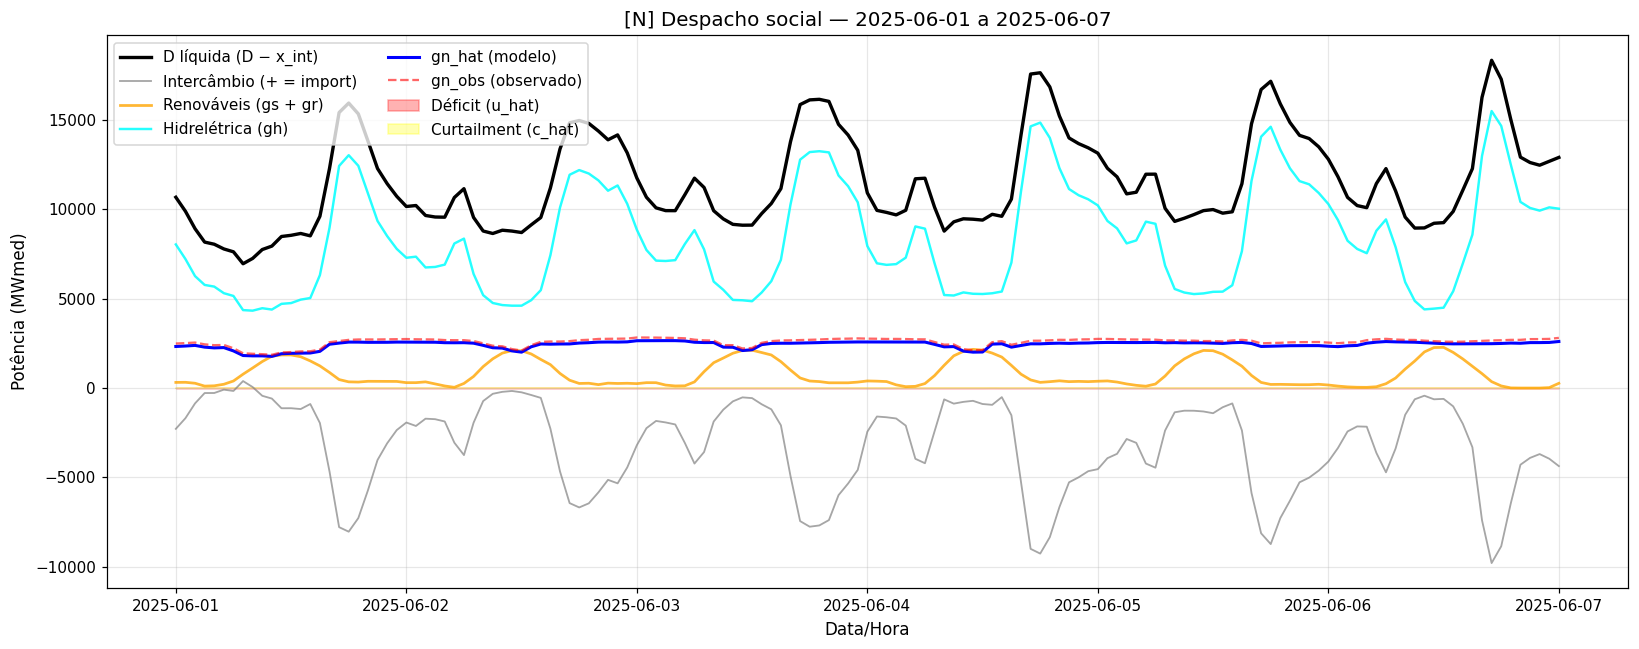

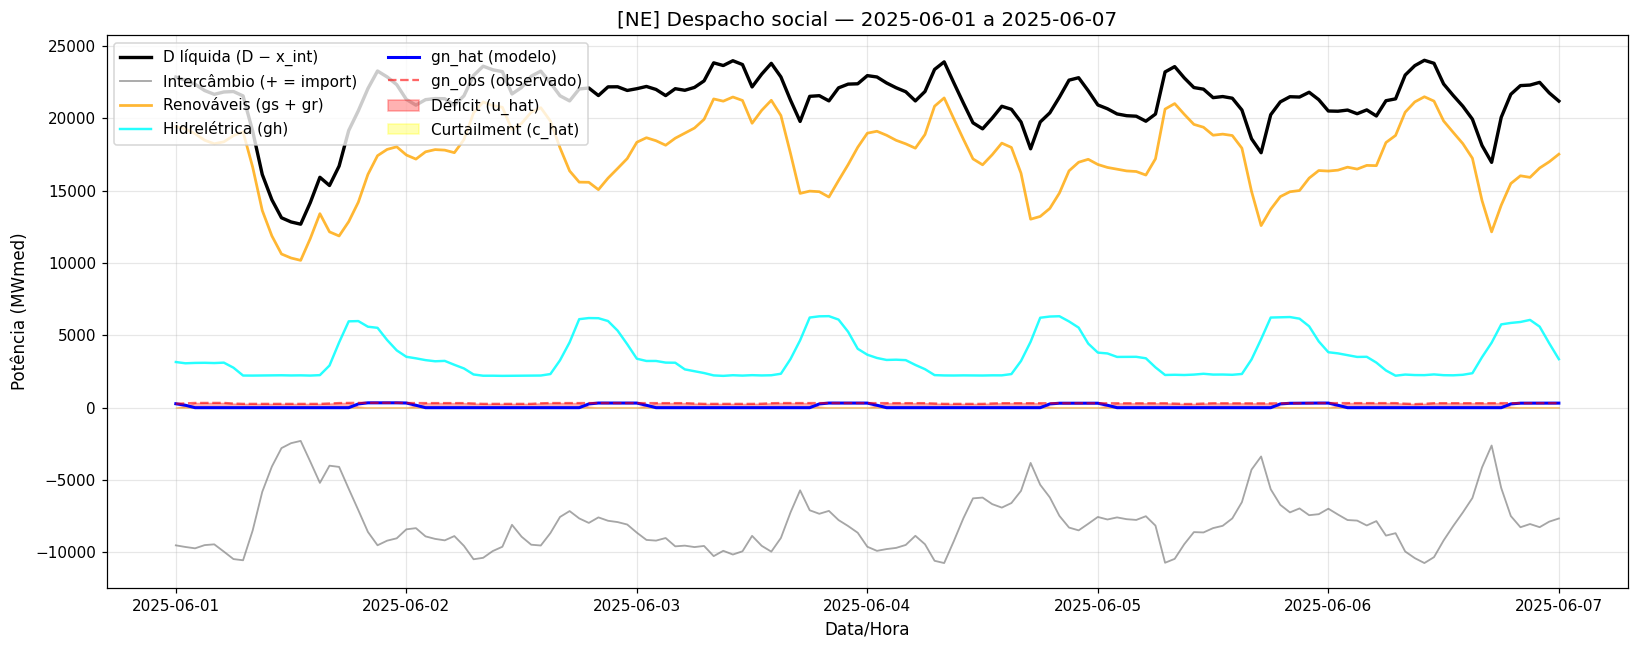

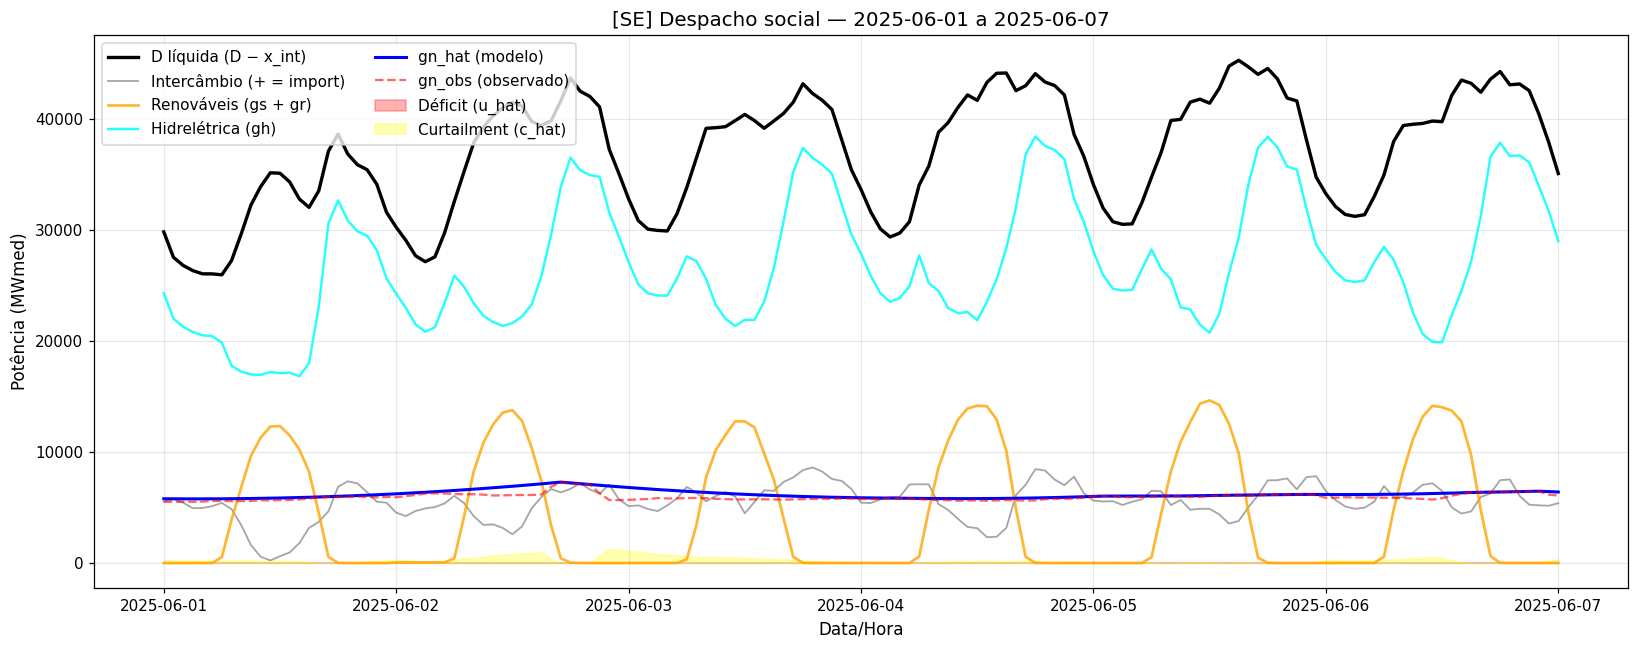

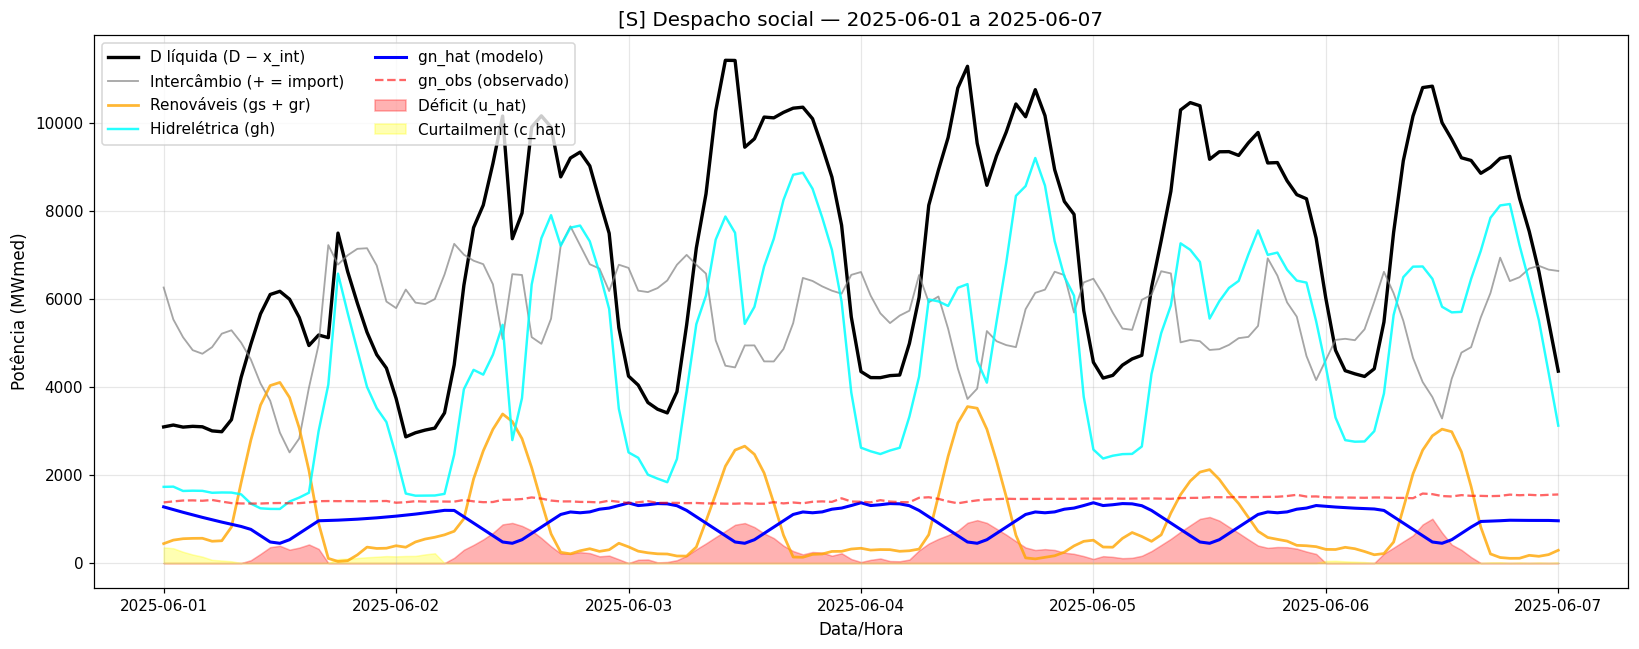

In [14]:
windows = [
    ("2025-01-01", "2025-01-07", "Primeira semana (Janeiro)"),
    ("2025-06-01", "2025-06-07", "Primeira semana de Junho"),
]

reference = pred_interc if not pred_interc.empty else pred_no_interc

if not reference.empty:
    for start, end, desc in windows:
        print(f"\n{'━'*60}")
        print(f"  {desc}: {start} → {end}")
        print(f"{'━'*60}")
        for ss in SUBSYS_ORDER:
            plot_temporal_window(reference, ss, start=start, end=end)

## 8. Scatter: Despacho Observado vs. Otimizado

Gráfico de dispersão (observado vs. predito) com linha de identidade — quanto mais próximo da diagonal, melhor o modelo.

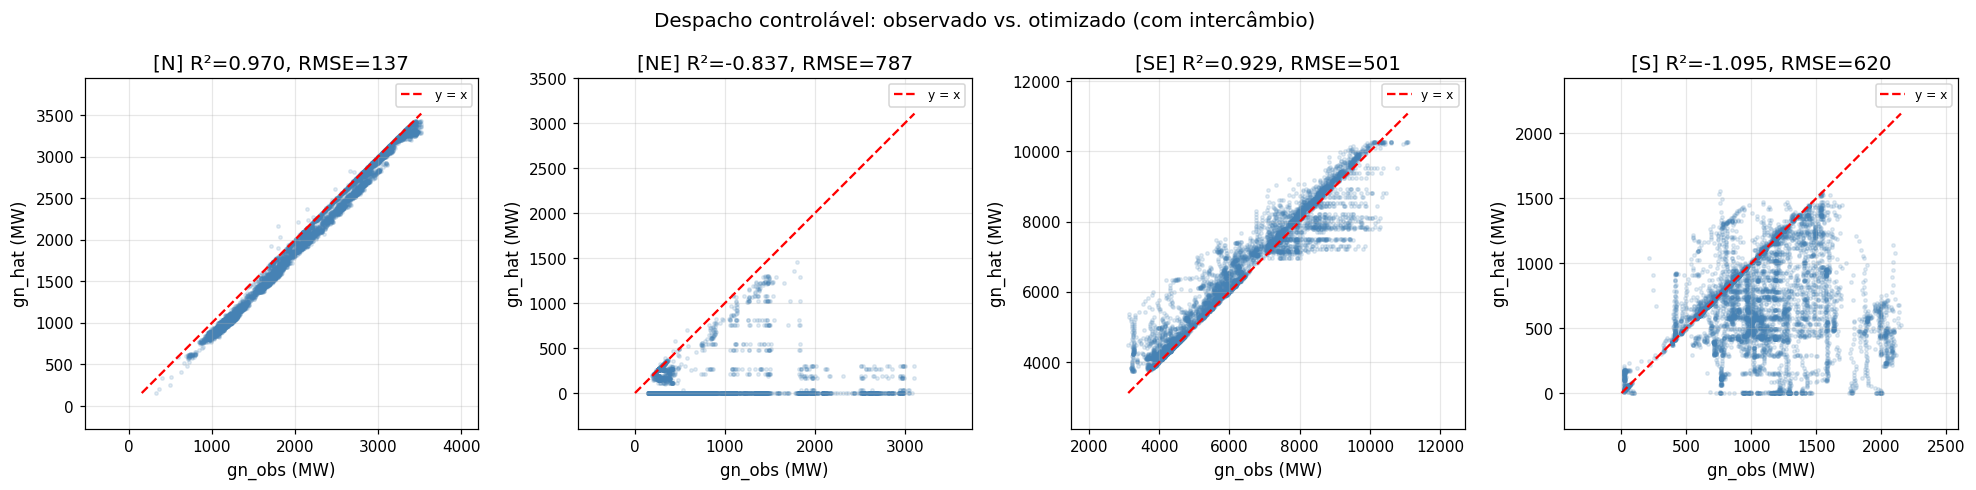

In [15]:
if not pred_interc.empty:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for ax, ss in zip(axes, SUBSYS_ORDER):
        sub = pred_interc[pred_interc["id_subsistema"] == ss].dropna(subset=["gn_obs", "gn_hat"])
        if len(sub) == 0:
            ax.set_title(f"[{ss}] Sem dados")
            continue

        ax.scatter(sub["gn_obs"], sub["gn_hat"], alpha=0.15, s=5, color="steelblue")
        lo = min(sub["gn_obs"].min(), sub["gn_hat"].min())
        hi = max(sub["gn_obs"].max(), sub["gn_hat"].max())
        ax.plot([lo, hi], [lo, hi], "--", color="red", linewidth=1.5, label="y = x")

        m = metrics(sub["gn_obs"], sub["gn_hat"])
        ax.set_title(f"[{ss}] R²={m['r2']:.3f}, RMSE={m['rmse']:.0f}")
        ax.set_xlabel("gn_obs (MW)")
        ax.set_ylabel("gn_hat (MW)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="datalim")

    fig.suptitle("Despacho controlável: observado vs. otimizado (com intercâmbio)", fontsize=13)
    fig.tight_layout()
    plt.show()

## 9. Resumo Final

Síntese dos resultados com os principais indicadores por cenário.

In [16]:
print("=" * 70)
print("RESUMO FINAL")
print("=" * 70)

for name, pred in [("Com intercâmbio", pred_interc), ("Sem intercâmbio", pred_no_interc)]:
    if pred.empty:
        continue
    pred_c = pred.copy()
    pred_c["regime"] = classify_regime(pred_c)

    print(f"\n--- {name} ---")
    for ss in SUBSYS_ORDER:
        sub = pred_c[pred_c["id_subsistema"] == ss]
        if len(sub) == 0:
            continue
        m = metrics(sub["gn_obs"], sub["gn_hat"])
        n_normal = (sub["regime"] == "normal").sum()
        n_curtail = (sub["regime"] == "curtailment").sum()
        n_deficit = (sub["regime"] == "deficit").sum()
        print(f"  [{ss}] R²={m['r2']:.3f} | RMSE={m['rmse']:,.0f} MW | "
              f"Normal={n_normal} | Curtail={n_curtail} | Deficit={n_deficit}")

print("\n✓ Análise de modelos de despacho concluída.")

RESUMO FINAL

--- Com intercâmbio ---
  [N] R²=0.970 | RMSE=137 MW | Normal=6816 | Curtail=26 | Deficit=286
  [NE] R²=-0.837 | RMSE=787 MW | Normal=425 | Curtail=409 | Deficit=6294
  [SE] R²=0.929 | RMSE=501 MW | Normal=1267 | Curtail=4988 | Deficit=873
  [S] R²=-1.095 | RMSE=620 MW | Normal=1369 | Curtail=4024 | Deficit=1735

--- Sem intercâmbio ---
  [N] R²=-0.692 | RMSE=1,029 MW | Normal=67 | Curtail=4575 | Deficit=2486
  [NE] R²=-1.053 | RMSE=832 MW | Normal=0 | Curtail=6512 | Deficit=616
  [SE] R²=-1.883 | RMSE=3,185 MW | Normal=118 | Curtail=1418 | Deficit=5592
  [S] R²=-1.007 | RMSE=606 MW | Normal=63 | Curtail=1462 | Deficit=5603

✓ Análise de modelos de despacho concluída.
